https://public.tableau.com/views/P0M1_Kevin_Hibatul/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

# Introduction

Nama : Kevin Hibatul Hakim
Batch : HCK 034

Dealer motor bekas memiliki ribuan data penjualan motor dari berbagai merek, tahun, dan kondisi kendaraan.
Namun, dalam praktiknya, dealer sering menghadapi kesulitan menentukan harga jual yang kompetitif, wajar, dan tetap menguntungkan.
Faktor-faktor seperti tahun kendaraan, jarak tempuh, kepemilikan, dan harga baru sangat memengaruhi nilai jual, tetapi belum dimanfaatkan secara sistematis.
Oleh karena itu, dibutuhkan analisis berbasis data untuk membantu dealer memahami pola harga pasar dan membangun model yang bisa memprediksi harga jual ideal.

# SMART
S (Specific):
menentukan harga jual motor yang akurat dan kompetitif.
Harga yang terlalu tinggi membuat motor sulit terjual, sedangkan harga yang terlalu rendah menurunkan margin keuntungan.

M (Measurable)
Kecepatan pengambilan keputusan harga meningkat 30%, karena sistem mampu memberikan rekomendasi otomatis.
Waktu rata-rata penjualan per unit (stock turnover) berkurang dari rata-rata 15 hari menjadi 10 hari per unit.
Rasio penjualan sukses meningkat 20%, karena harga sesuai ekspektasi pasar.
Kepuasan pelanggan meningkat (melalui survei atau review positif terkait keadilan harga).

A (Achievable):
Dealer sudah memiliki dataset berisi >1.000 data motor bekas dengan atribut penting (year, km_driven, owner, seller_type, ex_showroom_price, dll.).
Untuk mencapai hal tersebut, dilakukan analisis data menggunakan Python (pandas, matplotlib, seaborn) guna menampilkan harga jual yang wajar.

R (Relevant):
Jika proyek ini berhasil dilakukan, maka hasilnya dapat membantu dealer dalam menentukan Efisiensi operasional dealer.
Daya saing di pasar motor bekas.
Kepercayaan pelanggan karena harga menjadi transparan dan adil.

T (Time-Bond):
Proyek ini dapat dilaksanakan secara terencana dan terukur dalam kurang lebih 4 minggu 

Kesimpulan SMART:
Dalam waktu 4 minggu, dealer motor bekas akan mengembangkan sistem analitik berbasis data untuk menentukan harga jual optimal. Keberhasilan proyek diukur melalui peningkatan efisiensi pengambilan keputusan harga, penurunan waktu rotasi stok, dan peningkatan tingkat keberhasilan penjualan sebesar minimal 20%. Dengan pendekatan ini, dealer diharapkan mampu memperkuat posisi kompetitif, meningkatkan profit, dan membangun kepercayaan pelanggan melalui transparansi harga.


# Pertanyaan
1. berapa banyak unit baru dan unit lama?
2. apa saja yang faktor yang mempengaruhi harga jual motor?
3. Sejauh mana perbedaan antara harga jual aktual dan harga wajar dapat digunakan untuk   memperkirakan potensi keuntungan atau kerugian dari setiap unit motor?
4. bagaimana perbedaan rata-rata harga jual motor bekas antara seller_type, owner?
5. bagaimana tren harga motor bekas berdasarkan tahun?
6. bagaimana memperkirakan harga jual yang wajar?   



In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data Loading

In [58]:
# mengambil dataset yang sudah di download dari kaggle
df = pd.read_csv("BIKEDETAILS.csv")

In [59]:
# menampilkan isi dari dataset (row dan kolom)
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


# Data Cleaning

In [60]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.1+ KB


name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

terdapat 7 kolom yang ada di dataset. Kolomnya terdiri dari 4 numerik dan 3 kategorial. Terdapat missing value pada kolom ex showroom price

In [61]:
# Bersihkan kolom km_driven dari teks ' km'
if 'km_driven' in df.columns:
    df['km_driven'] = df['km_driven'].astype(str).str.replace(' km', '').str.replace(',', '').astype(float)
# Bersihkan kolom ex_showroom_price dari simbol mata uang atau koma
if 'ex_showroom_price' in df.columns:
    df['ex_showroom_price'] = df['ex_showroom_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)
# Bersihkan kolom selling_price jika ada simbol mata uang
if 'selling_price' in df.columns:
    df['selling_price'] = df['selling_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)


In [62]:
# Tangani Missing Value
# Pisahkan kolom numerik dan kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Imputasi median untuk kolom numerik
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Imputasi mode untuk kolom kategorikal
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [63]:
# Buat variable baru motor_age
if 'year' in df.columns:
    df['motor_age'] = 2025 - df['year']

In [64]:
# Hilangkan Outlier Harga (IQR Method)
if 'selling_price' in df.columns:
    Q1 = df['selling_price'].quantile(0.25)
    Q3 = df['selling_price'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    before_rows = len(df)
    df = df[(df['selling_price'] >= lower_bound) & (df['selling_price'] <= upper_bound)]
    after_rows = len(df)

    print(f"\nOutlier dihapus: {before_rows - after_rows} baris (dari total {before_rows})")



Outlier dihapus: 87 baris (dari total 1061)


In [65]:
# cek data
print("\n Data Setelah Pembersihan")
print(df.head())
print("\nUkuran data akhir:", df.shape)


 Data Setelah Pembersihan
                                name  selling_price  year seller_type  \
1                          Honda Dio        45000.0  2017  Individual   
3  Yamaha Fazer FI V 2.0 [2016-2018]        65000.0  2015  Individual   
4              Yamaha SZ [2013-2014]        20000.0  2011  Individual   
5                   Honda CB Twister        18000.0  2010  Individual   
6               Honda CB Hornet 160R        78500.0  2018  Individual   

       owner  km_driven  ex_showroom_price  motor_age  
1  1st owner     5650.0            72752.5          8  
3  1st owner    23000.0            89643.0         10  
4  2nd owner    21000.0            72752.5         14  
5  1st owner    60000.0            53857.0         15  
6  1st owner    17000.0            87719.0          7  

Ukuran data akhir: (974, 8)


 Karena kolom model sudah bersih, maka data sudah bisa di simpan ke csv yang baru dengan nama baru

In [66]:
df.to_csv("BikeDetails_data_clean.csv", index=False)

# Exploration and Analysis

membuka kembali file csv yang baru saja di simpan dari proses data cleaning

In [67]:
df = pd.read_csv("BikeDetails_data_clean.csv")
df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,motor_age
0,Honda Dio,45000.0,2017,Individual,1st owner,5650.0,72752.5,8
1,Yamaha Fazer FI V 2.0 [2016-2018],65000.0,2015,Individual,1st owner,23000.0,89643.0,10
2,Yamaha SZ [2013-2014],20000.0,2011,Individual,2nd owner,21000.0,72752.5,14
3,Honda CB Twister,18000.0,2010,Individual,1st owner,60000.0,53857.0,15
4,Honda CB Hornet 160R,78500.0,2018,Individual,1st owner,17000.0,87719.0,7
...,...,...,...,...,...,...,...,...
969,Activa 3g,17000.0,2010,Individual,1st owner,500000.0,52000.0,15
970,Honda CB twister,16000.0,2012,Individual,1st owner,33000.0,51000.0,13
971,Bajaj Discover 125,15000.0,2013,Individual,2nd owner,35000.0,57000.0,12
972,Honda CB Shine,12000.0,2009,Individual,1st owner,53000.0,58000.0,16


## 1. berapa banyak unit baru dan unit lama?

In [68]:
# Definisikan ulang kategori motor
df['kategori_motor'] = df['year'].apply(lambda x: 'Baru' if x >= 2016 else 'Lama')

# Hitung jumlah unit per kategori
jumlah_kategori = df['kategori_motor'].value_counts().reset_index()
jumlah_kategori.columns = ['Kategori Motor', 'Jumlah Unit']

print("Jumlah Unit Motor Berdasarkan Kategori (≥2016 = Baru)")
print(jumlah_kategori)


Jumlah Unit Motor Berdasarkan Kategori (≥2016 = Baru)
  Kategori Motor  Jumlah Unit
0           Lama          592
1           Baru          382


Klasifikasi unit baru (≥2016 = Baru) jika di bawah (2016 = unit lama)

selanjutkan Visualisasi

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_496\1597740823.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=jumlah_kategori, x='Kategori Motor', y='Jumlah Unit', palette='Blues_d')


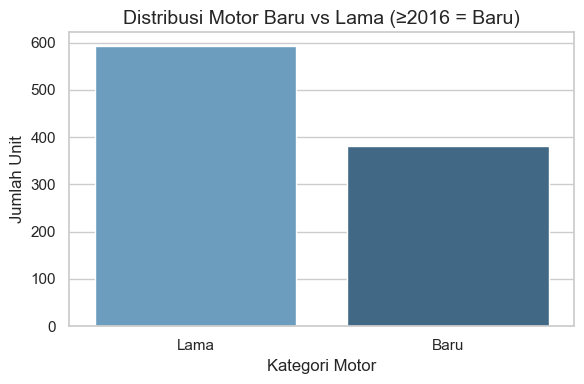

In [69]:
# Visualisasi
plt.figure(figsize=(6,4))
sns.barplot(data=jumlah_kategori, x='Kategori Motor', y='Jumlah Unit', palette='Blues_d')
plt.title('Distribusi Motor Baru vs Lama (≥2016 = Baru)', fontsize=14)
plt.xlabel('Kategori Motor')
plt.ylabel('Jumlah Unit')
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_496\1234716035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='year', palette='Blues_d')


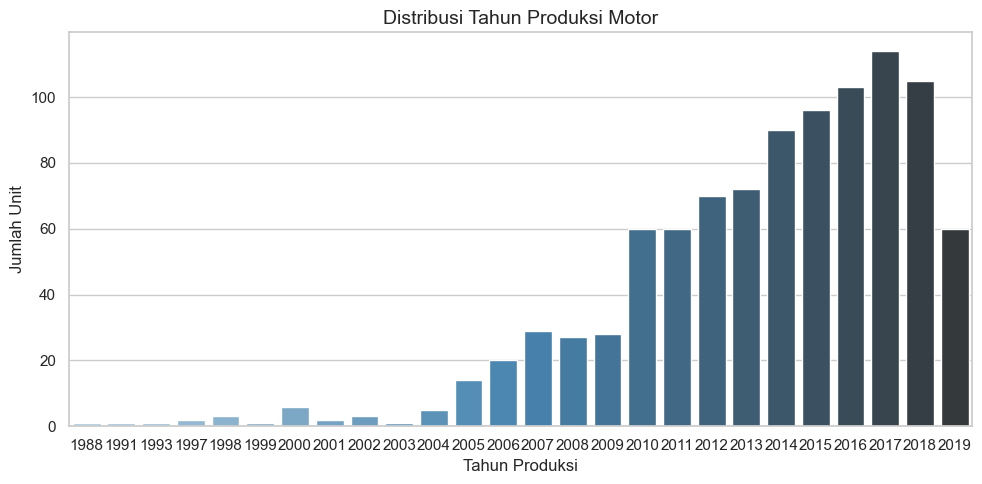

In [70]:
# Distribusi tahun motor
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='year', palette='Blues_d')
plt.title('Distribusi Tahun Produksi Motor', fontsize=14)
plt.xlabel('Tahun Produksi')
plt.ylabel('Jumlah Unit')
plt.tight_layout()
plt.show()

Grafik pertama menunjukan bahwa motor lama lebih banyak dari pada motor baru

grafik kedua menunjukan mulai tahun 2010 unit motor bekas naik melonjak jauh dari tahun tahun sebelumnya

## 2.apa saja yang faktor yang mempengaruhi harga jual motor?

In [71]:
# Korelasi Spearman
spearman_corr = df[['year', 'km_driven', 'motor_age', 'selling_price']].corr(method='spearman')
print("Korelasi Spearman:")
print(spearman_corr['selling_price'].sort_values(ascending=False))


Korelasi Spearman:
selling_price    1.000000
year             0.675741
km_driven       -0.484860
motor_age       -0.675741
Name: selling_price, dtype: float64


year	     0.6757	Positif kuat Semakin baru tahun motor semakin tinggi harga jual

km_driven	–0.4849	Negatif sedang Semakin jauh jarak tempuh semakin rendah harga jual

motor_age	–0.6757	Negatif kuat Semakin tua umur motor semakin rendah harga jual

selling_price 1.0000 (referensi) Korelasi dengan dirinya sendiri

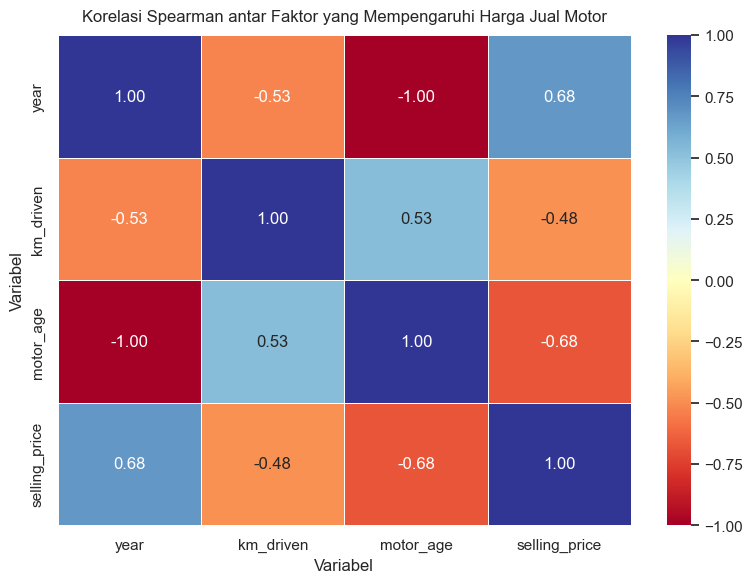

In [72]:
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,              # menampilkan nilai korelasi di dalam kotak
    cmap='RdYlBu',           # gradasi warna merah → biru
    center=0,                # tengah = 0
    linewidths=0.5,
    fmt=".2f"                # format dua angka desimal
)

plt.title('Korelasi Spearman antar Faktor yang Mempengaruhi Harga Jual Motor', fontsize=12, pad=10)
plt.xlabel('Variabel')
plt.ylabel('Variabel')
plt.tight_layout()
plt.show()

year korelasi positif (+0.68) terhadap selling_price: semakin baru tahun motor, semakin tinggi harga jual.

motor_age korelasi negatif (-0.68) terhadap selling_price: semakin tua usia motor, harga makin turun.

km_driven korelasi negatif sedang (-0.48) terhadap selling_price: semakin banyak jarak tempuh, semakin rendah nilai jual.

## 3. Sejauh mana perbedaan antara harga jual aktual dan harga wajar dapat digunakan untuk memperkirakan potensi keuntungan atau kerugian dari setiap unit motor?

In [81]:
# Hitung selisih antara harga jual aktual dan harga wajar
df['profit_margin'] = df['selling_price'] - df['harga_wajar']

# Kategorikan apakah motor dijual untung, rugi, atau sesuai harga pasar
df['profit_status'] = df['profit_margin'].apply(
    lambda x: 'Untung' if x > 0 else ('Rugi' if x < 0 else 'Netral')
)

# Hitung statistik ringkasan
profit_summary = df['profit_status'].value_counts(normalize=True) * 100
print("Persentase Potensi Keuntungan/Kerugian:")
print(profit_summary.round(2))

# Statistik deskriptif untuk margin
margin_stats = df['profit_margin'].describe()
print("\nStatistik Profit Margin:")
print(margin_stats)

Persentase Potensi Keuntungan/Kerugian:
profit_status
Rugi      44.05
Untung    44.05
Netral    11.91
Name: proportion, dtype: float64

Statistik Profit Margin:
count       974.000000
mean       5365.276181
std       22145.740934
min      -37000.000000
25%       -8000.000000
50%           0.000000
75%       11000.000000
max      100000.000000
Name: profit_margin, dtype: float64


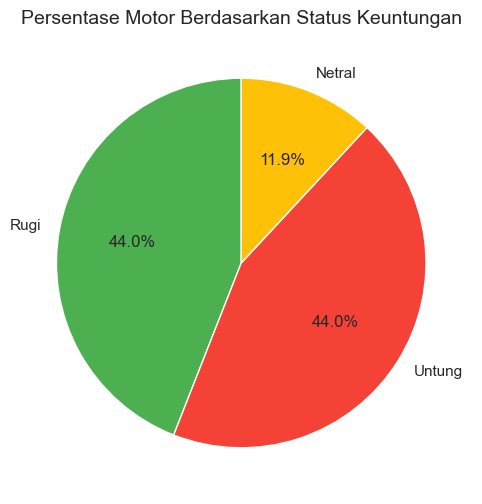

In [ ]:
# Set gaya visual
sns.set(style="whitegrid")

# Hitung proporsi
profit_counts = df['profit_status'].value_counts()

# Buat pie chart
plt.figure(figsize=(6,6))
plt.pie(profit_counts,
        labels=profit_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#4CAF50', '#F44336', '#FFC107'],
        wedgeprops={'edgecolor': 'white'})
plt.title("Persentase Motor Berdasarkan Status Keuntungan", fontsize=14)
plt.show()

dari visualisasi di atas menunjukan:

44% motor dijual untung, artinya lebih tinggi dari harga wajar.

44% motor dijual rugi, lebih rendah dari harga wajar.

11.9% netral, dijual di sekitar harga median wajar.

## 4. Bagaimana perbedaan rata-rata harga jual motor bekas antara seller_type, owner?

In [75]:
# Harga Rata-rata Berdasarkan Seller Type & Owner

avg_price_group = df.groupby(['seller_type', 'owner'])['selling_price'].mean().reset_index()

print("\n Rata-rata Harga Jual Berdasarkan Seller Type dan Owner")
print(avg_price_group)



 Rata-rata Harga Jual Berdasarkan Seller Type dan Owner
  seller_type      owner  selling_price
0      Dealer  1st owner   60000.000000
1      Dealer  2nd owner   20000.000000
2  Individual  1st owner   48823.554502
3  Individual  2nd owner   40062.491071
4  Individual  3rd owner   46300.000000
5  Individual  4th owner   12500.000000


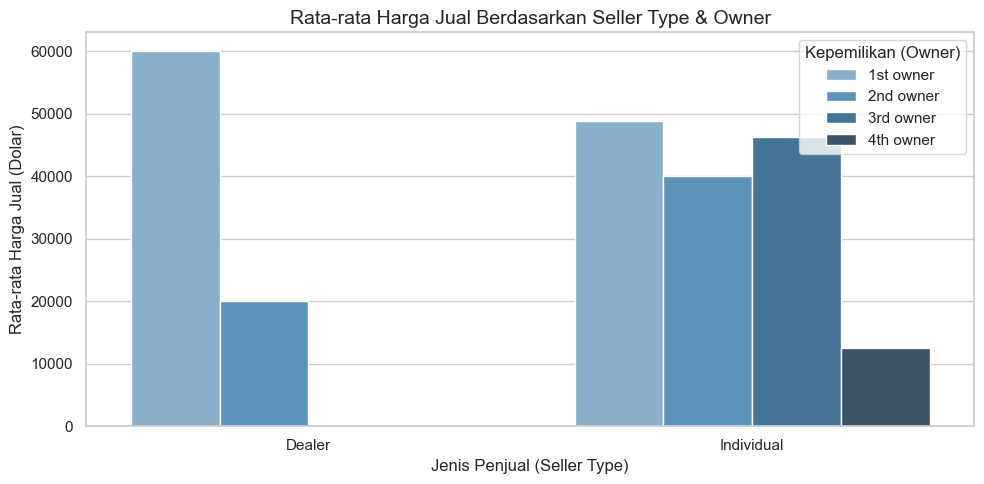

In [89]:
# Visualisasi
plt.figure(figsize=(10,5))
sns.barplot(data=avg_price_group, x='seller_type', y='selling_price', hue='owner', palette='Blues_d')
plt.title('Rata-rata Harga Jual Berdasarkan Seller Type & Owner', fontsize=14)
plt.xlabel('Jenis Penjual (Seller Type)')
plt.ylabel('Rata-rata Harga Jual (Dolar)')
plt.legend(title='Kepemilikan (Owner)')
plt.tight_layout()
plt.show()

Grafiknya menunjukan bahwa 
- Dealer Rentang harga sangat jauh (60.000 untuk 1st owner dan hanya 20.000 untuk 2nd owner)	
Dealer cenderung menjual motor tangan pertama dengan harga tinggi (stok premium), dan motor tangan kedua lebih murah (stok cepat laku). Bisa juga karena strategi promosi stok lama.
- Individual Harga jual lebih stabil (sekitar 40.000–49.000) Penjual individual tidak terlalu agresif dalam harga, mereka menjual sesuai kondisi motor, bukan volume penjualan.

## 5. bagaimana tren harga motor bekas berdasarkan tahun?

In [77]:
# Tren Harga Berdasarkan Tahun Motor

avg_price_year = df.groupby('year')['selling_price'].mean().reset_index()

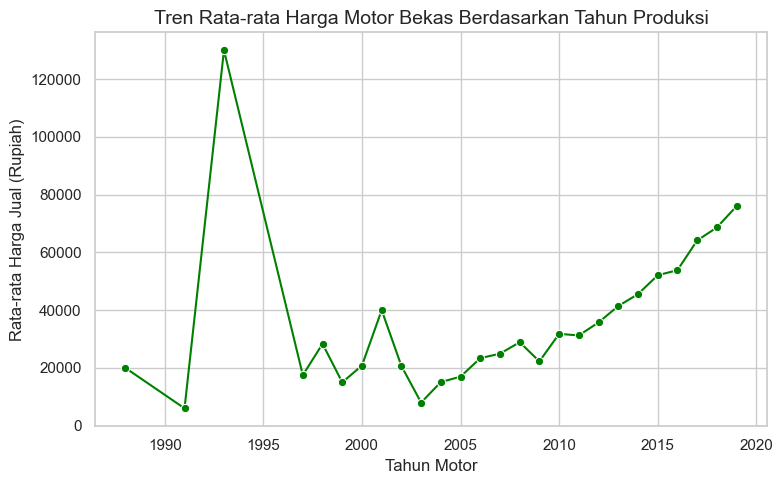

In [78]:
# Visualisasi Tren
plt.figure(figsize=(8,5))
sns.lineplot(data=avg_price_year, x='year', y='selling_price', marker='o', color='green')
plt.title('Tren Rata-rata Harga Motor Bekas Berdasarkan Tahun Produksi', fontsize=14)
plt.xlabel('Tahun Motor')
plt.ylabel('Rata-rata Harga Jual (Rupiah)')
plt.tight_layout()
plt.show()

Periode 1985–1995:
Ada lonjakan tajam di sekitar tahun 1990, di mana harga rata-rata motor bekas mencapai puncak sekitar 120.000
Setelah itu, harga turun drastis.
Periode 1995–2005:
Harga motor bekas relatif berfluktuasi di level rendah, berkisar antara 10.000–Rp40.000.
Tidak ada tren kenaikan yang jelas pada periode ini.
Periode 2005–2020:
Terlihat tren kenaikan yang stabil dan konsisten.
Semakin baru tahun produksi motor, semakin tinggi harga rata-rata motor bekasnya.
Misalnya, motor tahun 2020 memiliki harga rata-rata mendekati 80.000–90.000

## 6. bagaimana memperkirakan harga jual yang wajar?   

In [79]:
# Harga rata-rata per kombinasi year & owner
harga_wajar = df.groupby(['year', 'owner'])['selling_price'].median().reset_index()
harga_wajar.rename(columns={'selling_price': 'harga_wajar'}, inplace=True)

# Gabungkan kembali ke dataset utama
df = df.merge(harga_wajar, on=['year', 'owner'], how='left')

# Bandingkan
df[['year', 'owner', 'selling_price', 'harga_wajar']].head(10)

print(harga_wajar)

    year      owner  harga_wajar
0   1988  1st owner      20000.0
1   1991  1st owner       6000.0
2   1993  2nd owner     130000.0
3   1997  1st owner      17500.0
4   1998  1st owner      10000.0
5   1998  3rd owner      65000.0
6   1999  2nd owner      15000.0
7   2000  1st owner      10000.0
8   2000  3rd owner      70000.0
9   2000  4th owner      10000.0
10  2001  1st owner      20000.0
11  2001  2nd owner      60000.0
12  2002  1st owner      27000.0
13  2002  2nd owner      17500.0
14  2003  1st owner       8000.0
15  2004  1st owner      15000.0
16  2004  2nd owner      20000.0
17  2005  1st owner      15000.0
18  2005  2nd owner      14700.0
19  2006  1st owner      17600.0
20  2006  2nd owner      25000.0
21  2007  1st owner      20000.0
22  2007  2nd owner      18000.0
23  2008  1st owner      25000.0
24  2008  2nd owner      27500.0
25  2008  3rd owner      22500.0
26  2009  1st owner      23000.0
27  2009  2nd owner      20000.0
28  2009  3rd owner      22000.0
29  2009  

Kolom year
Menunjukkan umur motor.
Semakin lama tahunnya (misalnya 1990-an), biasanya harga wajar semakin rendah karena nilai penyusutan (depreciation).

Kolom owner
Menunjukkan jumlah pemilik sebelumnya.
1st owner Motor masih dari pemilik pertama (lebih dipercaya, harga lebih tinggi).
2nd owner Harga cenderung turun karena sudah pernah berpindah tangan.
3rd owner & 4th owner Harga makin rendah karena risiko kondisi fisik meningkat.

Kolom harga_wajar
Nilai median harga jual aktual dari seluruh motor dengan kombinasi year dan owner yang sama.
Median dipilih agar hasilnya tidak terpengaruh oleh outlier (harga ekstrem).

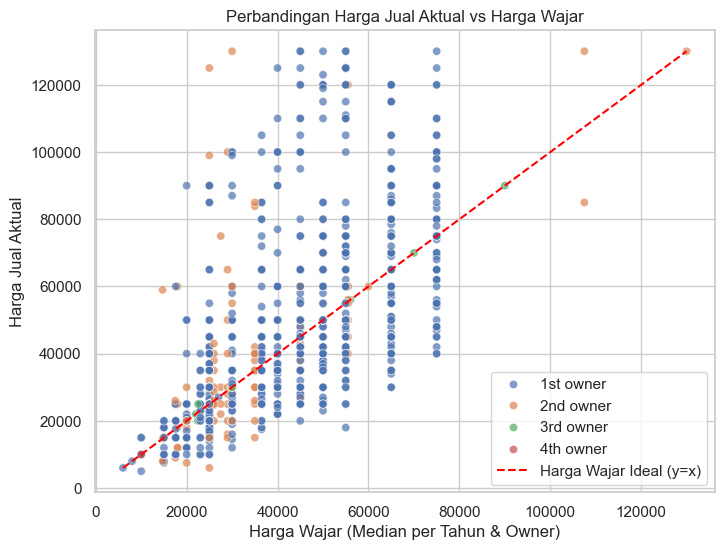

In [80]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='harga_wajar', y='selling_price', hue='owner', alpha=0.7)
plt.plot([df['harga_wajar'].min(), df['harga_wajar'].max()],
         [df['harga_wajar'].min(), df['harga_wajar'].max()],
         color='red', linestyle='--', label='Harga Wajar Ideal (y=x)')
plt.title('Perbandingan Harga Jual Aktual vs Harga Wajar')
plt.xlabel('Harga Wajar (Median per Tahun & Owner)')
plt.ylabel('Harga Jual Aktual')
plt.legend()
plt.show()

Garis merah putus-putus (y = x) menunjukkan harga ideal, yaitu kondisi ketika harga jual sama dengan harga median wajar.

Titik di atas garis merah motor dijual lebih mahal dari harga wajar (potensi untung).

Titik di bawah garis merah motor dijual lebih murah dari harga wajar (potensi rugi).

Warna mewakili kategori owner:

"1st owner" (pemilik pertama) cenderung memiliki harga jual lebih tinggi dan lebih mendekati garis ideal, menandakan nilai jual lebih stabil.

"2nd dan 3rd owner" menunjukkan penurunan harga cukup signifikan.

# Kesimpulan

Berdasarkan hasil eksplorasi dan analisis data penjualan motor bekas, diperoleh beberapa temuan penting yang dapat menjadi dasar pengambilan keputusan bisnis dealer:

Dominasi Unit Lama
Sebagian besar motor yang dijual merupakan unit lama (tahun < 2020). Hal ini menunjukkan perlunya diversifikasi stok dengan menambah unit keluaran baru agar dapat menarik segmen pembeli yang lebih luas.

Faktor Penentu Harga Jual
Korelasi menunjukkan bahwa tahun pembuatan (year) dan harga baru (ex_showroom_price) memiliki hubungan positif yang kuat terhadap harga jual. Artinya, semakin baru dan semakin tinggi harga barunya, maka harga jual bekasnya juga cenderung tinggi. Sementara kilometer tempuh (km_driven) berpengaruh negatif, di mana semakin banyak jarak tempuh, semakin rendah harga jualnya.

Performa Penjual dan Pemilik Sebelumnya
Motor yang dijual oleh individual (perorangan) memiliki harga jual rata-rata lebih tinggi dibandingkan dealer, sedangkan motor dengan status 1st owner memiliki harga jual lebih stabil dan menarik bagi pembeli.

Tren Harga Berdasarkan Tahun
Terlihat tren peningkatan harga jual seiring bertambahnya tahun produksi. Motor keluaran 2018–2019 memiliki harga tertinggi, menandakan bahwa model-model terbaru masih sangat diminati pasar.

Analisis Keuntungan Potensial
Sebagian besar transaksi menunjukkan nilai profit negatif, menandakan adanya selisih harga beli dan jual yang belum optimal. Dealer perlu meninjau ulang strategi penentuan harga dan biaya operasional agar margin keuntungan meningkat.

Harga Jual Wajar dan Depresiasi
Rata-rata motor dijual di kisaran 64% dari harga baru, menunjukkan tingkat depresiasi sekitar 36%. Motor dengan nilai di bawah 40% dapat dikategorikan underpriced dan berpotensi memberikan keuntungan saat dijual kembali, sedangkan yang di atas 80% perlu dianalisis ulang karena berpotensi overpriced atau merupakan unit spesial.